In [2]:
import os
import dotenv
import pymysql
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
# la funzione load_dotenv legge il file .env e ne mette il contenuto
# nelle variabili d'ambiente del sistema operativo
dotenv.load_dotenv(dotenv_path=".env", override=True)

# tramite la libreria os ("operating system") leggiamo le variabili
# d'ambiente, e trasferiamo il contenuto in delle variabili Python
username = os.getenv("username")
password = os.getenv("password")
hostname = os.getenv("hostname")
database = os.getenv("database2")

# creiamo la variabile "connection" che gestisce la connessione a database
connection = pymysql.connect(
    host=hostname,
    user=username,
    password=password,
    database=database,
    cursorclass=pymysql.cursors.DictCursor
)

In [10]:
cursor = connection.cursor()
query = "SELECT * FROM titanic;"
cursor.execute(query)
result = cursor.fetchall()
titanic = pd.DataFrame(result)

I ponti totali sono 8 ovvero i seguenti: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']


<Axes: xlabel='PClass1', ylabel='Frequency'>

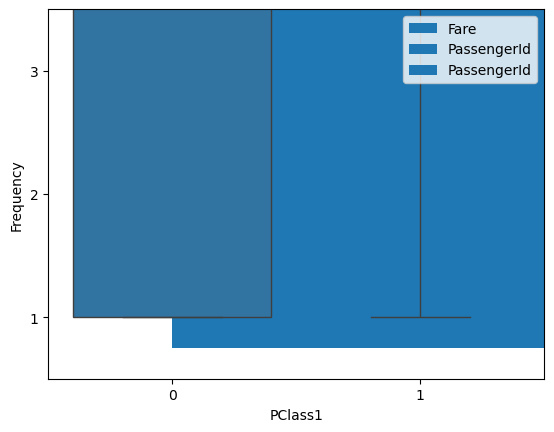

In [72]:
# quanti pontos c'erano sulla nave ? 
filtro = titanic.Cabin != ''
ponti_clean = titanic.Cabin[filtro]

ponti = []
for ponte in ponti_clean:
    ponti.append(ponte[0])

ponti = set(ponti)
ponti = list(ponti)
ponti.sort()
print(f"I ponti totali sono {len(ponti)} ovvero i seguenti: {ponti}")

#grafico n passeggeri per classe
titanic.groupby("PClass")["PassengerId"].count().plot(kind="barh")
titanic.groupby("Survived")["PassengerId"].count().plot(kind="bar")

# come si distribuiscono le fares
titanic.Fare = pd.to_numeric(titanic.Fare)
titanic["Fare"].plot(kind="hist")

# boxlplot età passeggeri vs classe
titanic.Age = pd.to_numeric(titanic.Age)
titanic["PClass1"] = titanic["PClass"].astype(str)
sns.boxplot(data=titanic, x="PClass1", y="Age")

I ponti totali sono 8 ovvero i seguenti: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']


<Axes: xlabel='PClass1', ylabel='Frequency'>

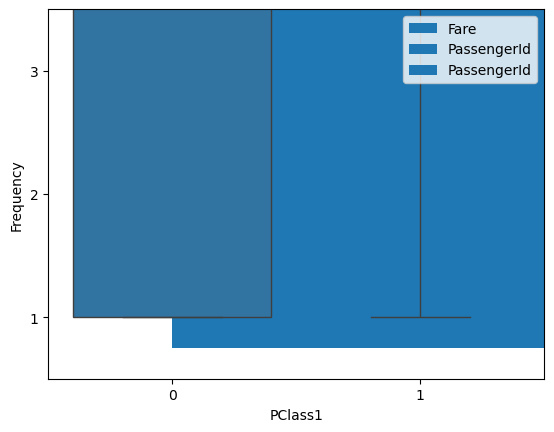

In [77]:
# quanti pontos c'erano sulla nave ? 
filtro = titanic.Cabin != ''
ponti_clean = titanic.Cabin[filtro]

ponti = []
for ponte in ponti_clean:
    ponti.append(ponte[0])

ponti = set(ponti)
ponti = list(ponti)
ponti.sort()
print(f"I ponti totali sono {len(ponti)} ovvero i seguenti: {ponti}")

#grafico n passeggeri per classe
titanic.groupby("PClass")["PassengerId"].count().plot(kind="barh")
titanic.groupby("Survived")["PassengerId"].count().plot(kind="bar")

# come si distribuiscono le fares
titanic.Fare = pd.to_numeric(titanic.Fare)
plt.figure()
titanic["Fare"].plot(kind="hist")

# boxlplot età passeggeri vs classe
titanic.Age = pd.to_numeric(titanic.Age)
titanic["PClass1"] = titanic["PClass"].astype(str)
plt.figure()
sns.boxplot(data=titanic, x="PClass1", y="Age")

# boxplot Fare e Survived
plt.figure()
sns.boxplot(data=titanic, x="Survived", y="Fare") # ne deduciamo che i ricchi sono sopravvissuti di più. Ovvero che nel gruppo 1 la distribuzione è più spostata verso l'alto in termini di Fare

<Axes: ylabel='Frequency'>

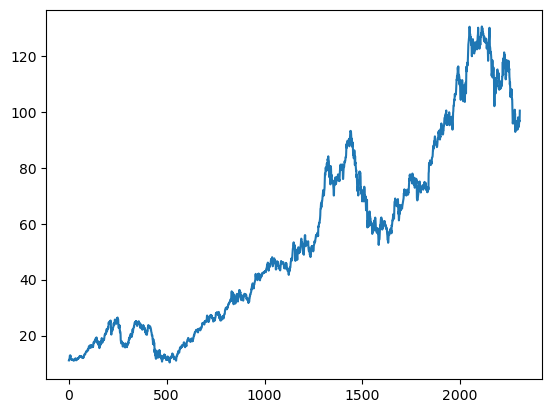

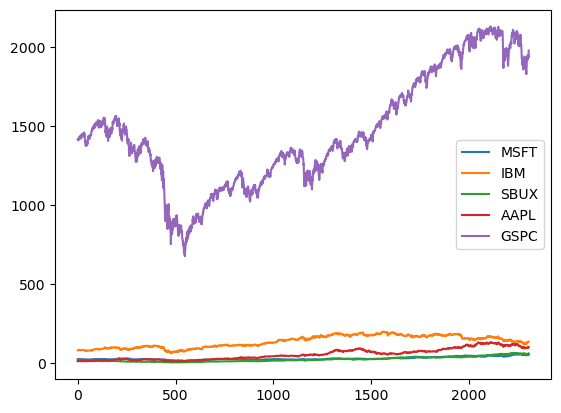

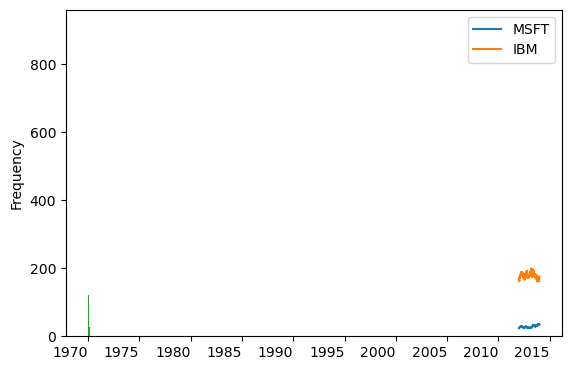

In [17]:
url = "https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/stockdata.csv"
stock = pd.read_csv(url)

# andamento apple
stock.AAPL.plot()

# andamento tutto
stock.plot()

# andamento microsoft e ibm nel 2012 e 2013
stock["Date"] = pd.to_datetime(stock["Date"], yearfirst=True)
filtro = (stock["Date"] >= "2012-01-01") & (stock["Date"] < "2014-01-01")
stockfiltrato = stock[filtro].set_index("Date")
stockfiltrato[["MSFT", "IBM"]].plot()

# istogramma Microsoft
stock.MSFT.plot(kind="hist")  # il range di valori che ha avuto più spesso è tra 20 e 25

<Axes: ylabel='Frequency'>

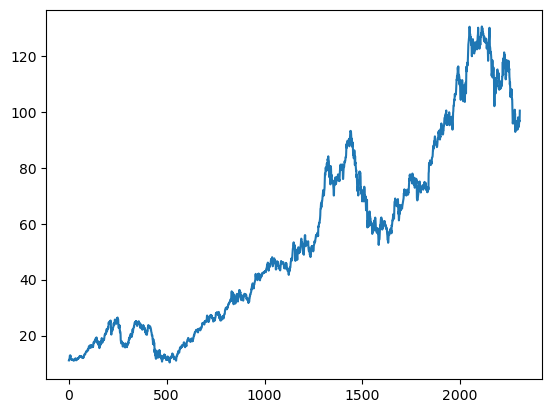

<Figure size 640x480 with 0 Axes>

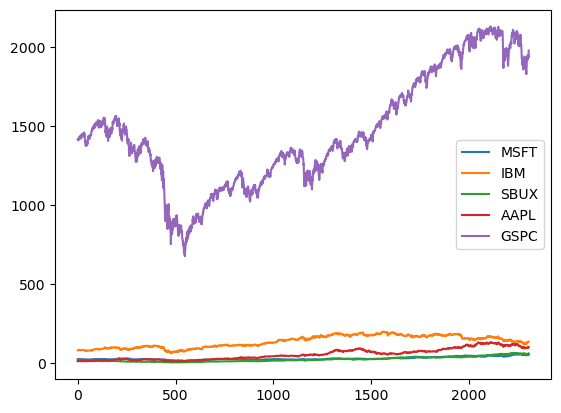

<Figure size 640x480 with 0 Axes>

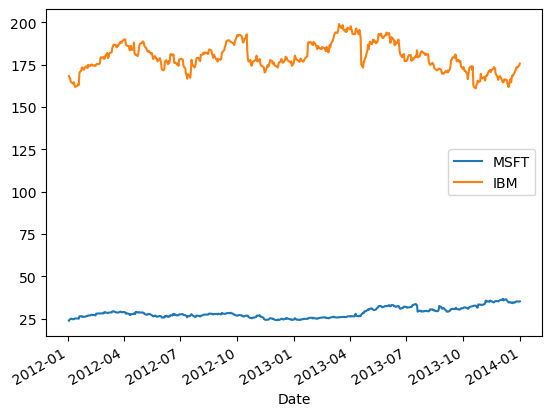

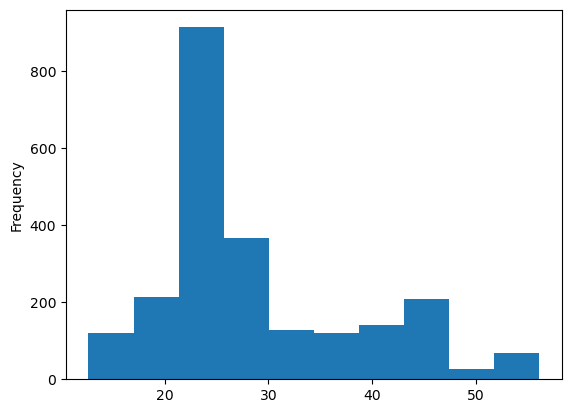

In [22]:
url = "https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/stockdata.csv"
stock = pd.read_csv(url)

# commento generale: se non metto plt.figure come suggerito da AI i grafici non vengono bene, se ne inserisco più di uno nella cella

# andamento apple
plt.figure()
stock.AAPL.plot()

# andamento tutto
plt.figure()
stock.plot()

# andamento microsoft e ibm nel 2012 e 2013
plt.figure()
stock["Date"] = pd.to_datetime(stock["Date"], yearfirst=True)
filtro = (stock["Date"] >= "2012-01-01") & (stock["Date"] < "2014-01-01")
stockfiltrato = stock[filtro].set_index("Date")
stockfiltrato[["MSFT", "IBM"]].plot()

# istogramma Microsoft
plt.figure()
stock.MSFT.plot(kind="hist")  # il range di valori che ha avuto più spesso è tra 20 e 25

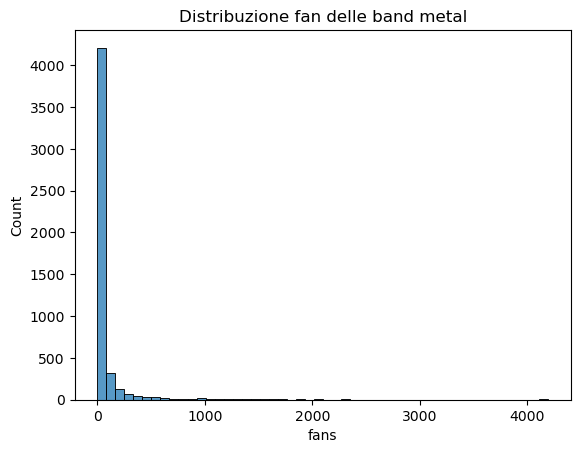

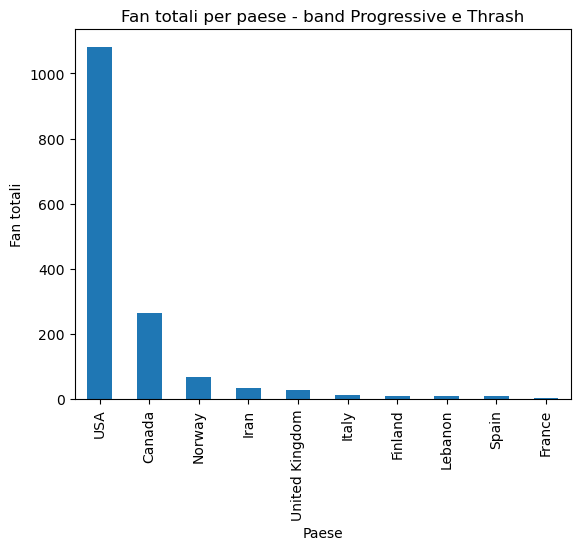

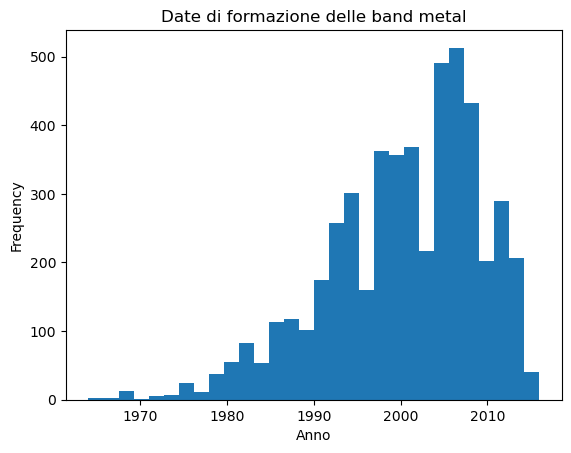

In [3]:
path = "C:/Users/giovanni.esposito/Desktop/EPICODE/M3 PYTHON/datasets/altri_dataset/metal_bands_2017.csv"
metal = pd.read_csv(path, encoding="latin1")


# istogramma fan - la distribuzione è molto sbilanciata verso sinistra
# la maggior parte delle band ha pochissimi fan, poche band hanno milioni di fan
plt.figure()
sns.histplot(data=metal, x="fans", bins=50)
plt.title("Distribuzione fan delle band metal")
plt.show()

# band che suonano sia Progressive che Thrash
filtro = metal.loc[:, "style"].str.contains("Progressive") & metal.loc[:, "style"].str.contains("Thrash")
metal_pt = metal[filtro]

plt.figure()
metal_pt.groupby("origin")["fans"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Fan totali per paese - band Progressive e Thrash")
plt.xlabel("Paese")
plt.ylabel("Fan totali")
plt.show()

# istogramma date di formazione
# dobbiamo convertire la colonna in numerico perché potrebbe avere valori non validi
metal["formed"] = pd.to_numeric(metal["formed"], errors="coerce")

plt.figure()
metal["formed"].dropna().plot(kind="hist", bins=30)
plt.title("Date di formazione delle band metal")
plt.xlabel("Anno")
plt.show()
# si nota un boom a partire dagli anni '80, picco negli anni '90-2000

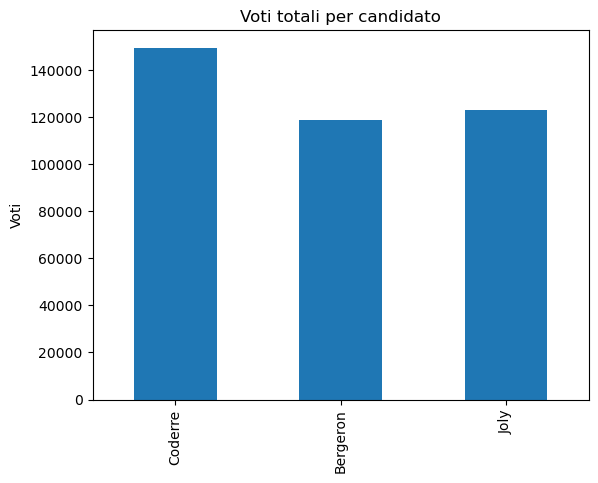

<Figure size 640x480 with 0 Axes>

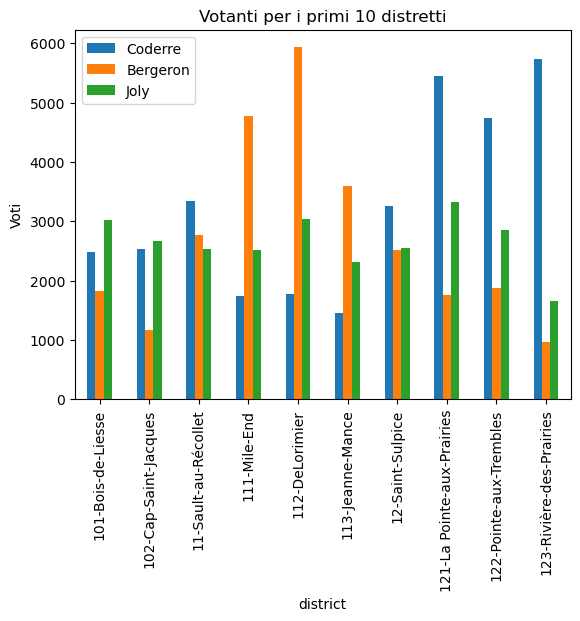

In [4]:
url = "https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/election.csv"
elections = pd.read_csv(url)
elections.head()

# voti totali per candidato
plt.figure()
elections[["Coderre", "Bergeron", "Joly"]].sum().plot(kind="bar")
plt.title("Voti totali per candidato")
plt.ylabel("Voti")
plt.show()

# votanti per i primi 10 distretti
plt.figure()
elections.head(10).set_index("district")[["Coderre", "Bergeron", "Joly"]].plot(kind="bar")
plt.title("Votanti per i primi 10 distretti")
plt.ylabel("Voti")
plt.show()

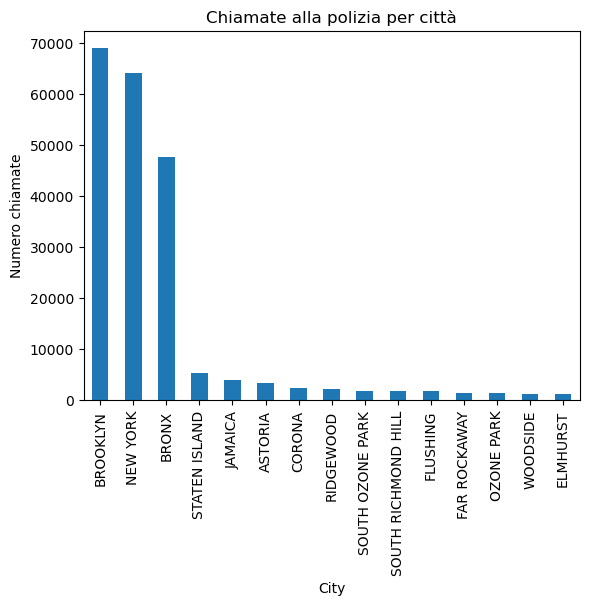

Latitudine: 40.498819681472185 - 40.91217840308113
Longitudine: -74.25127710072611 - -73.70230256557906
Segnalazioni case private: 146040


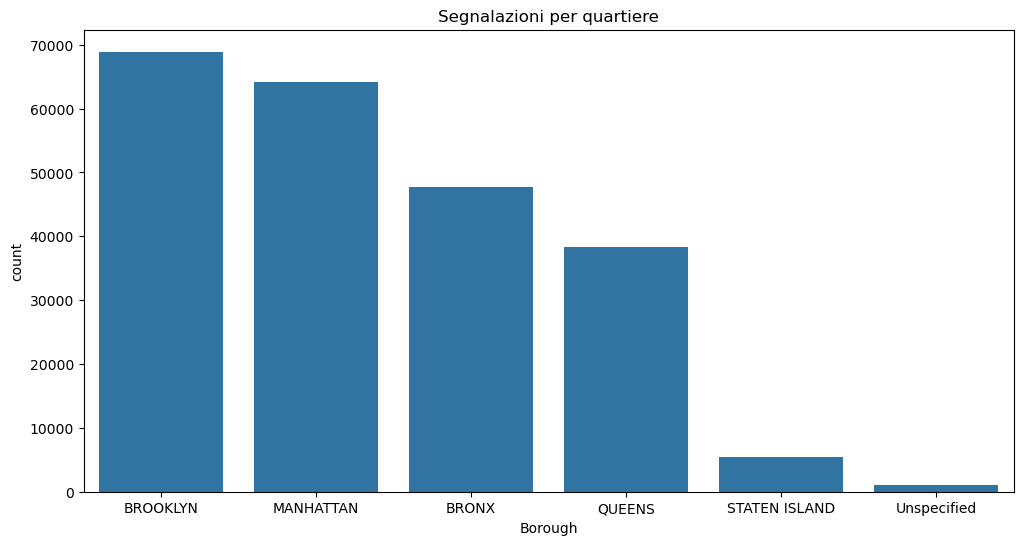

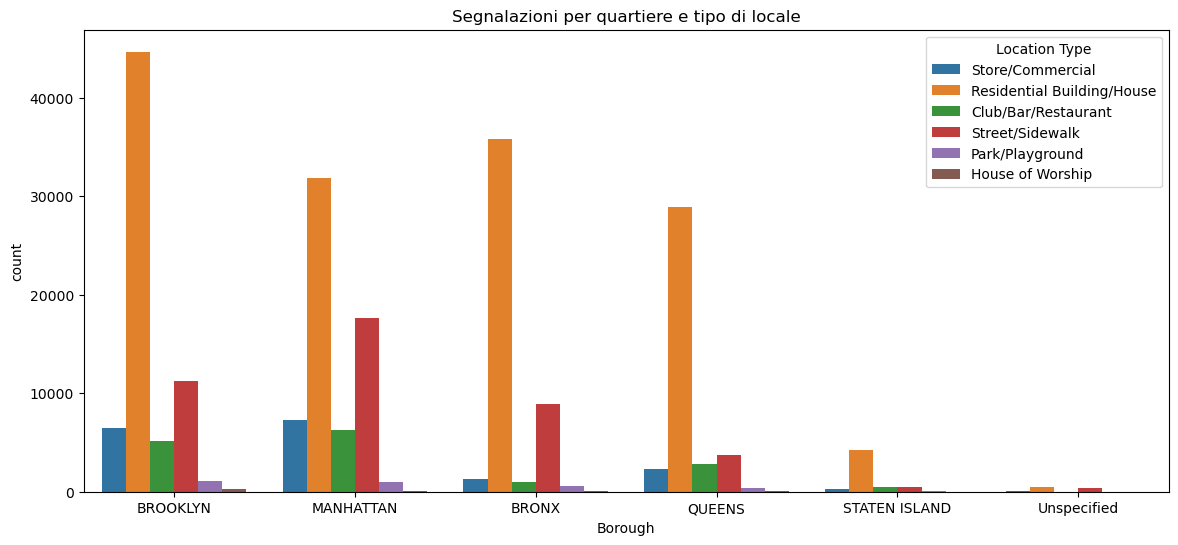

In [9]:
path = "C:/Users/giovanni.esposito/Desktop/EPICODE/M3 PYTHON/datasets/altri_dataset/party_in_nyc.csv"
party = pd.read_csv(path)
party.head()

# chiamate per città per tutti i tipi di locale
plt.figure()
party["City"].value_counts().head(15).plot(kind="bar")
plt.title("Chiamate alla polizia per città")
plt.ylabel("Numero chiamate")
plt.show()

# rettangolo latitudine e longitudine
print("Latitudine:", party["Latitude"].min(), "-", party["Latitude"].max())
print("Longitudine:", party["Longitude"].min(), "-", party["Longitude"].max())

# segnalazioni per case private
filtro_casa = party["Location Type"] == "Residential Building/House"
print("Segnalazioni case private:", filtro_casa.sum())

# conteggio segnalazioni per quartiere
plt.figure(figsize=(12, 6))
sns.countplot(data=party, x="Borough", order=party["Borough"].value_counts().index)
plt.title("Segnalazioni per quartiere")
plt.show()

# con hue="Location Type"
plt.figure(figsize=(14, 6))
sns.countplot(data=party, x="Borough", hue="Location Type", order=party["Borough"].value_counts().index)
plt.title("Segnalazioni per quartiere e tipo di locale")
plt.show()

In [8]:
print(party["Location Type"].value_counts())

Location Type
Residential Building/House    146040
Street/Sidewalk                42353
Store/Commercial               17617
Club/Bar/Restaurant            15766
Park/Playground                 3036
House of Worship                 602
Name: count, dtype: int64
